# Customer Analysis

This notebook focuses on analyzing customer behavior, customer value, and purchasing patterns.

Objectives:
- Identify high-value customers
- Analyze customer purchase frequency
- Perform RFM Analysis
- Segment customers based on purchasing behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()

In [2]:
df = pd.read_csv("../data/processed/online_retail_eda.csv")

C:\Users\M.Bilal\AppData\Local\Temp\ipykernel_15052\1974453864.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/online_retail_eda.csv")


In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth,Year,Month,Hour,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009,12,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,12,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009,12,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009,12,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009,12,7,Tuesday


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 14 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1007913 non-null  object 
 1   StockCode    1007913 non-null  object 
 2   Description  1007913 non-null  object 
 3   Quantity     1007913 non-null  int64  
 4   InvoiceDate  1007913 non-null  object 
 5   Price        1007913 non-null  float64
 6   Customer ID  779425 non-null   float64
 7   Country      1007913 non-null  object 
 8   Revenue      1007913 non-null  float64
 9   YearMonth    1007913 non-null  object 
 10  Year         1007913 non-null  int64  
 11  Month        1007913 non-null  int64  
 12  Hour         1007913 non-null  int64  
 13  DayOfWeek    1007913 non-null  object 
dtypes: float64(3), int64(4), object(7)
memory usage: 107.7+ MB


In [5]:
df.shape

(1007913, 14)

## Dataset Overview

The dataset contains cleaned retail transaction records with customer, product, and revenue information.

In [6]:
total_customers = df['Customer ID'].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 5,878


In [7]:
total_revenue = df['Revenue'].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £20,476,260.45


In [8]:
avg_revenue_customer = (
    df.groupby('Customer ID')['Revenue']
      .sum()
      .mean()
)

print(f"Average Revenue per Customer: £{avg_revenue_customer:,.2f}")

Average Revenue per Customer: £2,955.90


## Customer KPIs

These metrics provide a high-level view of customer contribution to overall business revenue.

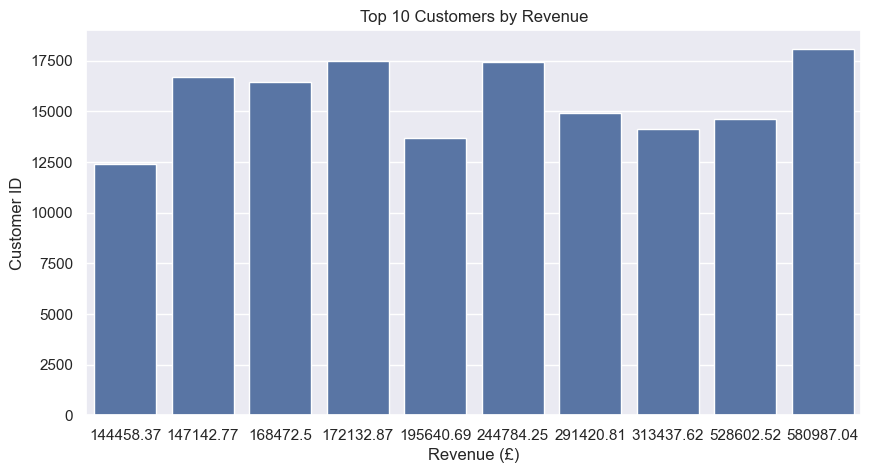

In [11]:
top_customers = (
    df.groupby('Customer ID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.show()

### Insight

- A small number of customers generate a significant portion of total revenue.
- These customers can be considered high-value customers.
- Retaining such customers is important for business growth.